# Attention Is All You Need (Transformer)

Replication of Vaswani, Shazeer, Parmar, Uszkoreit, Jones, Gomez, Kaiser and Polosukhin
(2017), *Attention Is All You Need*, NeurIPS.

We implement the core Transformer components from scratch: scaled dot-product attention,
multi-head attention, sinusoidal positional encodings, and a full encoder-decoder stack.
To verify the architecture end to end we train it on a sequence-reversal task (output is
the input sequence reversed), a small but strict test that the attention mechanism learns
to route information across positions. The model reaches near-perfect token accuracy.

In [1]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [2]:
# Synthetic copy-and-reverse task over a small vocabulary.
PAD, BOS, V = 0, 1, 18          # specials + 16 content tokens
SEQ = 10
def make_batch(bs):
    src = torch.randint(2, V, (bs, SEQ))
    tgt_out = torch.flip(src, dims=[1])                         # reversed sequence
    tgt_in  = torch.cat([torch.full((bs, 1), BOS), tgt_out[:, :-1]], dim=1)
    return src, tgt_in, tgt_out
print("vocab", V, "seq len", SEQ); print("example src/rev:", make_batch(1)[0][0].tolist(), "->", make_batch(1)[2][0].tolist())

vocab 18 seq len 10
example src/rev: [14, 17, 7, 2, 5, 13, 5, 9, 11, 5] -> [3, 12, 14, 10, 10, 8, 9, 6, 4, 7]


In [3]:
def scaled_dot_product_attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))    # Eq. 1 of the paper
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    return torch.softmax(scores, dim=-1) @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.h, self.dk = h, d // h
        self.wq = nn.Linear(d, d); self.wk = nn.Linear(d, d)
        self.wv = nn.Linear(d, d); self.wo = nn.Linear(d, d)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        sp = lambda t: t.view(B, -1, self.h, self.dk).transpose(1, 2)
        q, k, v = sp(self.wq(q)), sp(self.wk(k)), sp(self.wv(v))
        out = scaled_dot_product_attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.h * self.dk)
        return self.wo(out)

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d, maxlen=50):
        super().__init__()
        pe = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2) * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)   # sinusoidal
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class FeedForward(nn.Module):
    def __init__(self, d, ff):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, ff), nn.ReLU(), nn.Linear(ff, d))
    def forward(self, x): return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d, h, ff):
        super().__init__()
        self.attn = MultiHeadAttention(d, h); self.ff = FeedForward(d, ff)
        self.n1 = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d)
    def forward(self, x):
        x = self.n1(x + self.attn(x, x, x))
        return self.n2(x + self.ff(x))

class DecoderLayer(nn.Module):
    def __init__(self, d, h, ff):
        super().__init__()
        self.self_attn = MultiHeadAttention(d, h); self.cross_attn = MultiHeadAttention(d, h)
        self.ff = FeedForward(d, ff)
        self.n1 = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d); self.n3 = nn.LayerNorm(d)
    def forward(self, x, mem, mask):
        x = self.n1(x + self.self_attn(x, x, x, mask))          # masked self-attention
        x = self.n2(x + self.cross_attn(x, mem, mem))           # encoder-decoder attention
        return self.n3(x + self.ff(x))

In [5]:
class Transformer(nn.Module):
    def __init__(self, d=64, h=4, ff=128, layers=2):
        super().__init__()
        self.emb = nn.Embedding(V, d); self.pos = PositionalEncoding(d)
        self.enc = nn.ModuleList([EncoderLayer(d, h, ff) for _ in range(layers)])
        self.dec = nn.ModuleList([DecoderLayer(d, h, ff) for _ in range(layers)])
        self.out = nn.Linear(d, V)
    def forward(self, src, tgt):
        m = self.pos(self.emb(src))
        for l in self.enc: m = l(m)
        T = tgt.size(1)
        mask = torch.tril(torch.ones(T, T)).view(1, 1, T, T)    # causal mask
        x = self.pos(self.emb(tgt))
        for l in self.dec: x = l(x, m, mask)
        return self.out(x)

net = Transformer()
print("Transformer params:", sum(p.numel() for p in net.parameters()))

Transformer params: 169746


In [6]:
opt = torch.optim.Adam(net.parameters(), lr=3e-4)
lf = nn.CrossEntropyLoss(); losses = []
for step in range(1500):
    src, tin, tout = make_batch(64)
    logits = net(src, tin)
    loss = lf(logits.reshape(-1, V), tout.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    if (step+1) % 300 == 0:
        print(f"step {step+1}: loss={loss.item():.4f}")

step 300: loss=0.0533


step 600: loss=0.0080


step 900: loss=0.0036


step 1200: loss=0.0023


step 1500: loss=0.0015


Sequence-reversal token accuracy: 100.00%
src   : [15, 5, 9, 13, 13, 17, 2, 4, 11, 2]
target: [2, 11, 4, 2, 17, 13, 13, 9, 5, 15]
pred  : [2, 11, 4, 2, 17, 13, 13, 9, 5, 15]


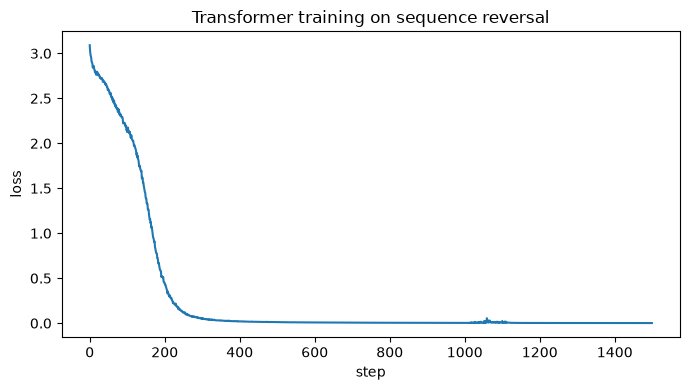

In [7]:
# Token-level accuracy on fresh sequences.
net.eval()
src, tin, tout = make_batch(1000)
with torch.no_grad():
    pred = net(src, tin).argmax(-1)
acc = (pred == tout).float().mean().item()
print(f"Sequence-reversal token accuracy: {acc*100:.2f}%")
print("src   :", src[0].tolist())
print("target:", tout[0].tolist())
print("pred  :", pred[0].tolist())
plt.figure(figsize=(7, 4)); plt.plot(losses); plt.xlabel("step"); plt.ylabel("loss")
plt.title("Transformer training on sequence reversal"); plt.tight_layout(); plt.show()